In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from math import log10

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [42]:
#Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)  # skip connection

In [43]:
#Encoder
class Encoder(nn.Module):
  def __init__(self, in_channels=3, hidden_dim=256, embed_dim=512):
    super().__init__()
    self.net = nn.Sequential(
        # 64x64x3 → 32x32x256
        nn.Conv2d(in_channels, hidden_dim, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        ResidualBlock(hidden_dim),

        # 32x32x256 -> 16x16x256
        nn.Conv2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        ResidualBlock(hidden_dim),

        # 16x16x256 -> 8x8x256
        nn.Conv2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        ResidualBlock(hidden_dim),

        # 8x8x256 -> 8x8x512
        nn.Conv2d(hidden_dim, embed_dim, kernel_size=3, stride=1, padding=1),
        ResidualBlock(embed_dim),
    )

  def forward(self, x):
    return self.net(x)

In [44]:
#Vector Quantizer
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings=1024, embed_dim=512, ema_decay=0.99):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embed_dim = embed_dim
        self.ema_decay = ema_decay

        # codebook vectors
        self.codebook = nn.Embedding(num_embeddings, embed_dim)
        self.codebook.weight.data.uniform_(-1.0 / num_embeddings, 1.0 / num_embeddings)

        # EMA tracking variables
        self.register_buffer("ema_cluster_size", torch.zeros(num_embeddings))
        self.register_buffer("ema_embed_sum", self.codebook.weight.data.clone())

    def forward(self, z):
        # z: [B, D, H, W]
        z = z.permute(0, 2, 3, 1).contiguous()  # [B, H, W, D]
        flat_z = z.view(-1, self.embed_dim)       # [B*H*W, D]

        #find nearest codebook entry
        distances = (
            flat_z.pow(2).sum(dim=1, keepdim=True)
            + self.codebook.weight.pow(2).sum(dim=1)
            - 2 * flat_z @ self.codebook.weight.t()
        )
        token_ids = distances.argmin(dim=1)  # [B*H*W]

        #look up quantized vectors
        quantized = self.codebook(token_ids).view(z.shape)

        # --- EMA codebook update ---
        if self.training:
            # One-hot encode the assignments
            encodings = F.one_hot(token_ids, self.num_embeddings).float()  # [B*H*W, K]

            # Update cluster sizes (how often each codebook entry is used)
            self.ema_cluster_size.data.mul_(self.ema_decay).add_(
                encodings.sum(0), alpha=1 - self.ema_decay
            )

            # Update embedding sums (sum of encoder outputs assigned to each entry)
            self.ema_embed_sum.data.mul_(self.ema_decay).add_(
                encodings.t() @ flat_z, alpha=1 - self.ema_decay
            )

            # Laplace smoothing to avoid division by zero
            n = self.ema_cluster_size.sum()
            cluster_size = (
                (self.ema_cluster_size + 1e-5)
                / (n + self.num_embeddings * 1e-5)
                * n
            )

            # Update codebook vectors
            self.codebook.weight.data.copy_(
                self.ema_embed_sum / cluster_size.unsqueeze(1)
            )

        # Commitment loss only (codebook is updated via EMA, not gradients)
        commitment_loss = F.mse_loss(z, quantized.detach())
        vq_loss = 0.25 * commitment_loss

        # Straight-through estimator
        quantized_st = z + (quantized - z).detach()
        quantized_st = quantized_st.permute(0, 3, 1, 2).contiguous()

        token_ids = token_ids.view(z.shape[0], z.shape[1], z.shape[2])

        return quantized_st, vq_loss, token_ids

    def reset_dead_entries(self, flat_z, max_reset=50):
        dead_mask = self.ema_cluster_size < 1.0
        dead_indices = dead_mask.nonzero(as_tuple=True)[0]
        num_dead = len(dead_indices)
        if num_dead == 0:
            return 0
        num_to_reset = min(num_dead, max_reset)
        reset_indices = dead_indices[torch.randperm(num_dead, device=flat_z.device)[:num_to_reset]]
        n = flat_z.shape[0]
        replace_indices = torch.randint(0, n, (num_to_reset,), device=flat_z.device)
        self.codebook.weight.data[reset_indices] = flat_z[replace_indices]
        self.ema_embed_sum.data[reset_indices] = flat_z[replace_indices]
        self.ema_cluster_size.data[reset_indices] = 1.0
        return num_to_reset

    def codebook_usage(self):
        """Check how many codebook entries are actually being used."""
        used = (self.ema_cluster_size > 1.0).sum().item()
        return used, self.num_embeddings

In [45]:
#Decoder
class Decoder(nn.Module):
    def __init__(self, out_channels=3, hidden_dim=256, embed_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            # 8x8x512 → 8x8x256
            nn.Conv2d(embed_dim, hidden_dim, kernel_size=3, stride=1, padding=1),
            ResidualBlock(hidden_dim),

            # 8x8x256 → 16x16x256
            nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            ResidualBlock(hidden_dim),

            # 16x16x256 → 32x32x256
            nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            ResidualBlock(hidden_dim),

            # 32x32x256 → 64x64x3
            nn.ConvTranspose2d(hidden_dim, out_channels, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        # x: [B, 512, 8, 8]
        # returns: [B, 3, 64, 64]
        return self.net(x)

In [46]:
# Full VQ-VAE
class VQVAE(nn.Module):
    def __init__(self, in_channels=3, hidden_dim=256, embed_dim=512,
                 num_embeddings=1024):
        super().__init__()
        self.encoder = Encoder(in_channels, hidden_dim, embed_dim)
        self.quantizer = VectorQuantizer(num_embeddings, embed_dim)
        self.decoder = Decoder(in_channels, hidden_dim, embed_dim)

    def forward(self, x):
        """
        Full forward pass:
            x → encode → quantize → decode → reconstruction

        Returns:
            recon: reconstructed frame [B, 3, 64, 64]
            vq_loss: vector quantization loss
            token_ids: discrete tokens [B, 8, 8]
        """
        z = self.encoder(x)
        quantized, vq_loss, token_ids = self.quantizer(z)
        recon = self.decoder(quantized)
        return recon, vq_loss, token_ids

    def encode(self, x):
        """Encode frames to discrete tokens (used after training)."""
        z = self.encoder(x)
        _, _, token_ids = self.quantizer(z)
        return token_ids  # [B, 8, 8]

    def decode_from_tokens(self, token_ids):
        """Decode discrete tokens back to frames (used for visualization)."""
        quantized = self.quantizer.codebook(token_ids)  # [B, 8, 8, 512]
        quantized = quantized.permute(0, 3, 1, 2)       # [B, 512, 8, 8]
        return self.decoder(quantized)                   # [B, 3, 64, 64]

In [47]:
# """
# Quick test to check the model is working.
# """

# if __name__ == "__main__":
#     model = VQVAE()
#     total_params = sum(p.numel() for p in model.parameters())
#     encoder_params = sum(p.numel() for p in model.encoder.parameters())
#     decoder_params = sum(p.numel() for p in model.decoder.parameters())
#     codebook_params = sum(p.numel() for p in model.quantizer.parameters())

#     print(f"Total parameters:    {total_params:,}")
#     print(f"  Encoder:           {encoder_params:,}")
#     print(f"  Codebook:          {codebook_params:,}")
#     print(f"  Decoder:           {decoder_params:,}")

#     # Fake batch
#     x = torch.randn(4, 3, 64, 64)
#     recon, vq_loss, tokens = model(x)

#     print(f"\nInput shape:          {x.shape}")
#     print(f"Reconstruction shape: {recon.shape}")
#     print(f"Token IDs shape:      {tokens.shape}")
#     print(f"Token ID range:       {tokens.min()} - {tokens.max()}")
#     print(f"VQ Loss:              {vq_loss.item():.4f}")
#     print(f"\nCompression: {64*64*3} values → {tokens.shape[1]*tokens.shape[2]} tokens ({64*64*3 / (tokens.shape[1]*tokens.shape[2]):.0f}x)")
#     print(f"Codebook: {model.quantizer.num_embeddings} visual words × {model.quantizer.embed_dim}-dim")

#     # Memory estimate for A100
#     param_mem = total_params * 4 / (1024**2)  # float32
#     print(f"\nModel memory: ~{param_mem:.0f} MB)")


In [48]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/procgen_data /content/procgen_data
print("Data copied to local disk!")

DATA_DIR = "/content/procgen_data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data copied to local disk!


In [49]:
class ProcgenFrameDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(h5_path, "r") as f:
            self.length = f["frames"].shape[0]
        self._file = None

    def _open(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r")
        return self._file

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        f = self._open()
        frame = f["frames"][idx].astype(np.float32) / 255.0  # [64, 64, 3], range [0,1]
        frame = np.transpose(frame, (2, 0, 1))                # [3, 64, 64] for PyTorch
        return torch.tensor(frame)

    def __del__(self):
        if self._file is not None:
            self._file.close()

In [50]:
# Load both games
coinrun_train = ProcgenFrameDataset(os.path.join(DATA_DIR, "coinrun_train.h5"))
starpilot_train = ProcgenFrameDataset(os.path.join(DATA_DIR, "starpilot_train.h5"))

# Combine into one dataset for training
combined_train = torch.utils.data.ConcatDataset([coinrun_train, starpilot_train])

train_loader = DataLoader(
    combined_train,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

print(f"CoinRun frames:  {len(coinrun_train):,}")
print(f"StarPilot frames: {len(starpilot_train):,}")
print(f"Total frames:    {len(combined_train):,}")
print(f"Batches per epoch: {len(train_loader)}")

CoinRun frames:  100,000
StarPilot frames: 100,000
Total frames:    200,000
Batches per epoch: 3125


In [51]:
#Initialise model and optimizer
model = VQVAE(
    in_channels=3,
    hidden_dim=256,
    embed_dim=64,
    num_embeddings=512,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 11,709,379


In [52]:
#Training loop
NUM_EPOCHS = 30
SAVE_DIR = "/content/drive/MyDrive/procgen_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

# Track losses for plotting
history = {"recon_loss": [], "vq_loss": [], "total_loss": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_recon = 0
    epoch_vq = 0
    epoch_total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        frames = batch.to(device)  # [B, 3, 64, 64]

        # Forward pass
        recon, vq_loss, tokens = model(frames)

        # Reconstruction loss — how well does the output match the input?
        recon_loss = F.mse_loss(recon, frames)

        # Total loss = reconstruction + VQ commitment
        total_loss = recon_loss + vq_loss

        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Track
        epoch_recon += recon_loss.item()
        epoch_vq += vq_loss.item()
        epoch_total += total_loss.item()

        pbar.set_postfix({
            "recon": f"{recon_loss.item():.4f}",
            "vq": f"{vq_loss.item():.4f}",
        })

    # Average losses for this epoch
    n_batches = len(train_loader)
    avg_recon = epoch_recon / n_batches
    avg_vq = epoch_vq / n_batches
    avg_total = epoch_total / n_batches

    history["recon_loss"].append(avg_recon)
    history["vq_loss"].append(avg_vq)
    history["total_loss"].append(avg_total)

    # Step scheduler
    # scheduler.step(avg_total)

    # Check codebook usage
    used, total_codes = model.quantizer.codebook_usage()

    #Reset dead entries ONCE per epoch
    with torch.no_grad():
        sample_batch = next(iter(train_loader)).to(device)
        z = model.encoder(sample_batch)
        flat_z = z.permute(0, 2, 3, 1).reshape(-1, model.quantizer.embed_dim)
        num_reset = model.quantizer.reset_dead_entries(flat_z)

    print(f"Epoch {epoch+1}: recon={avg_recon:.4f} | vq={avg_vq:.4f} | "
          f"codebook usage: {used}/{total_codes} ({100*used/total_codes:.0f}%)")

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        ckpt_path = os.path.join(SAVE_DIR, f"vqvae_epoch{epoch+1}.pt")
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
        }, ckpt_path)
        print(f"  Saved checkpoint: {ckpt_path}")

Epoch 1/30: 100%|██████████| 3125/3125 [07:37<00:00,  6.83it/s, recon=0.0052, vq=0.0011]


Epoch 1: recon=0.0173 | vq=0.0044 | codebook usage: 68/512 (13%)


Epoch 2/30: 100%|██████████| 3125/3125 [07:38<00:00,  6.81it/s, recon=0.0035, vq=0.0005]


Epoch 2: recon=0.0051 | vq=0.0007 | codebook usage: 117/512 (23%)


Epoch 3/30: 100%|██████████| 3125/3125 [07:36<00:00,  6.84it/s, recon=0.0626, vq=0.0220]


...

Epoch 28: recon=0.0070 | vq=0.0002 | codebook usage: 507/512 (99%)


Epoch 29/30: 100%|██████████| 3125/3125 [07:42<00:00,  6.75it/s, recon=0.0073, vq=0.0001]


Epoch 29: recon=0.0069 | vq=0.0001 | codebook usage: 504/512 (98%)


Epoch 30/30: 100%|██████████| 3125/3125 [07:40<00:00,  6.79it/s, recon=0.0063, vq=0.0001]


Epoch 30: recon=0.0067 | vq=0.0001 | codebook usage: 502/512 (98%)
  Saved checkpoint: /content/drive/MyDrive/procgen_checkpoints/vqvae_epoch30.pt


In [53]:
#Save final model
final_path = os.path.join(SAVE_DIR, "vqvae_final.pt")
torch.save({
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
}, final_path)
print(f"\nTraining complete. Final model saved to {final_path}")


Training complete. Final model saved to /content/drive/MyDrive/procgen_checkpoints/vqvae_final.pt


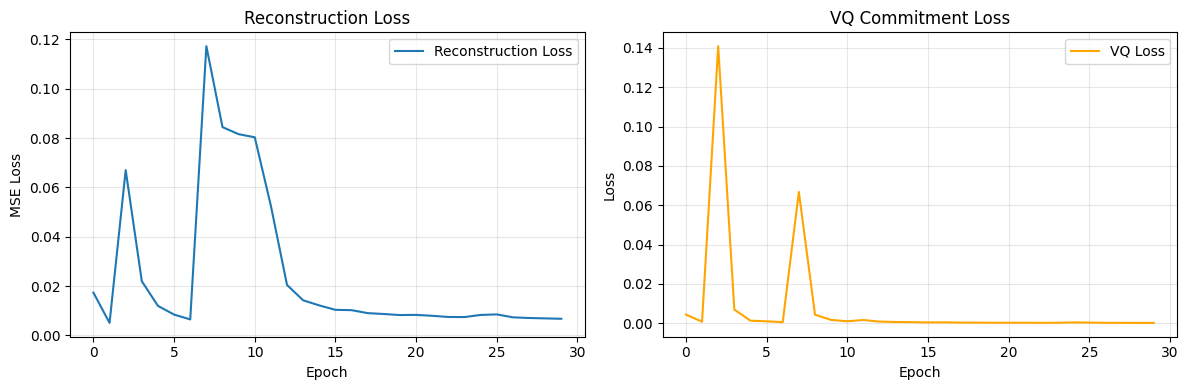

Training curves saved.


In [54]:
#Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["recon_loss"], label="Reconstruction Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Reconstruction Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["vq_loss"], label="VQ Loss", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("VQ Commitment Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")

In [55]:
#Visualize reconstructions
model.eval()

# Load a few test frames (unseen levels)
coinrun_test = ProcgenFrameDataset(os.path.join(DATA_DIR, "coinrun_test.h5"))
starpilot_test = ProcgenFrameDataset(os.path.join(DATA_DIR, "starpilot_test.h5"))

In [56]:
def visualize_reconstructions(dataset, title, n=8):
    indices = np.linspace(0, len(dataset) - 1, n, dtype=int)
    frames = torch.stack([dataset[i] for i in indices]).to(device)

    with torch.no_grad():
        recon, _, tokens = model(frames)

    # Clamp to valid range
    recon = recon.clamp(0, 1)

    fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))
    fig.suptitle(title, fontsize=14)

    for i in range(n):
        # Original
        axes[0, i].imshow(frames[i].cpu().permute(1, 2, 0))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_ylabel("Original", fontsize=10)

        # Reconstruction
        axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_ylabel("Reconstructed", fontsize=10)

        # Token grid
        axes[2, i].imshow(tokens[i].cpu(), cmap="viridis")
        axes[2, i].axis("off")
        if i == 0:
            axes[2, i].set_ylabel("Tokens (8×8)", fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"recon_{title.lower().replace(' ', '_')}.png"), dpi=150)
    plt.show()

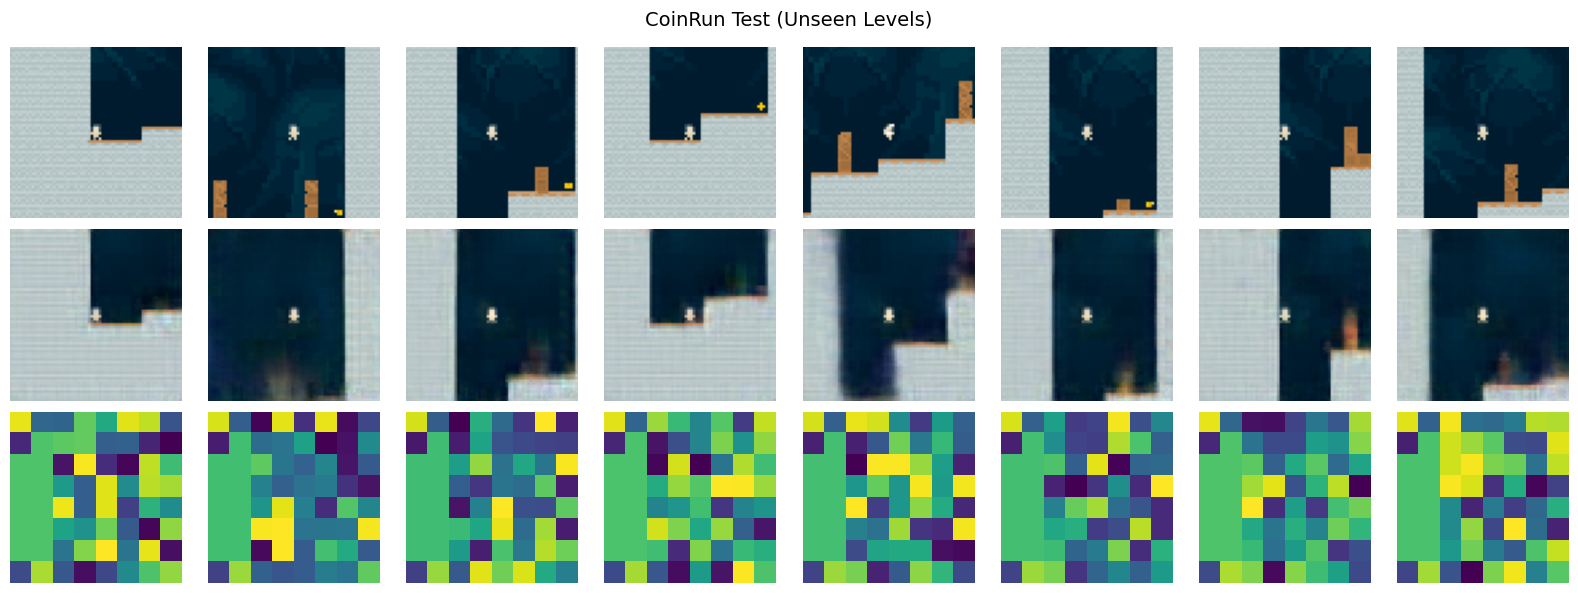

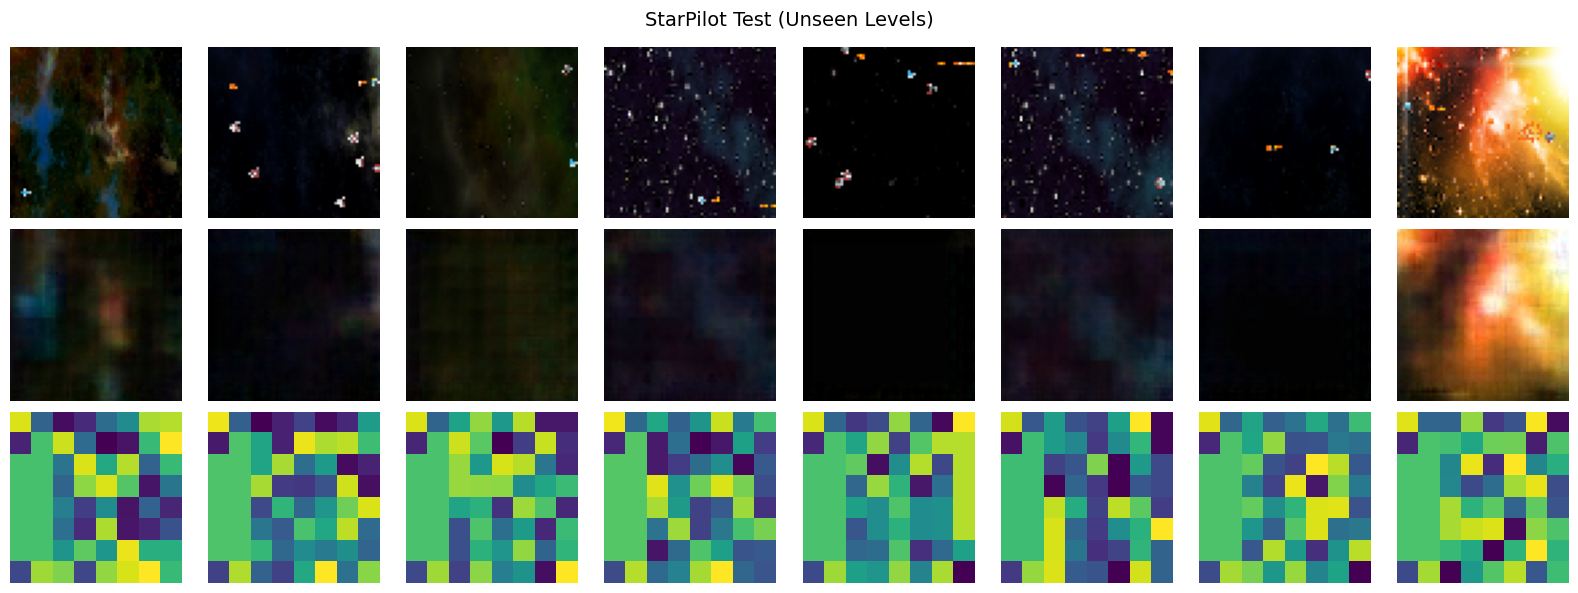

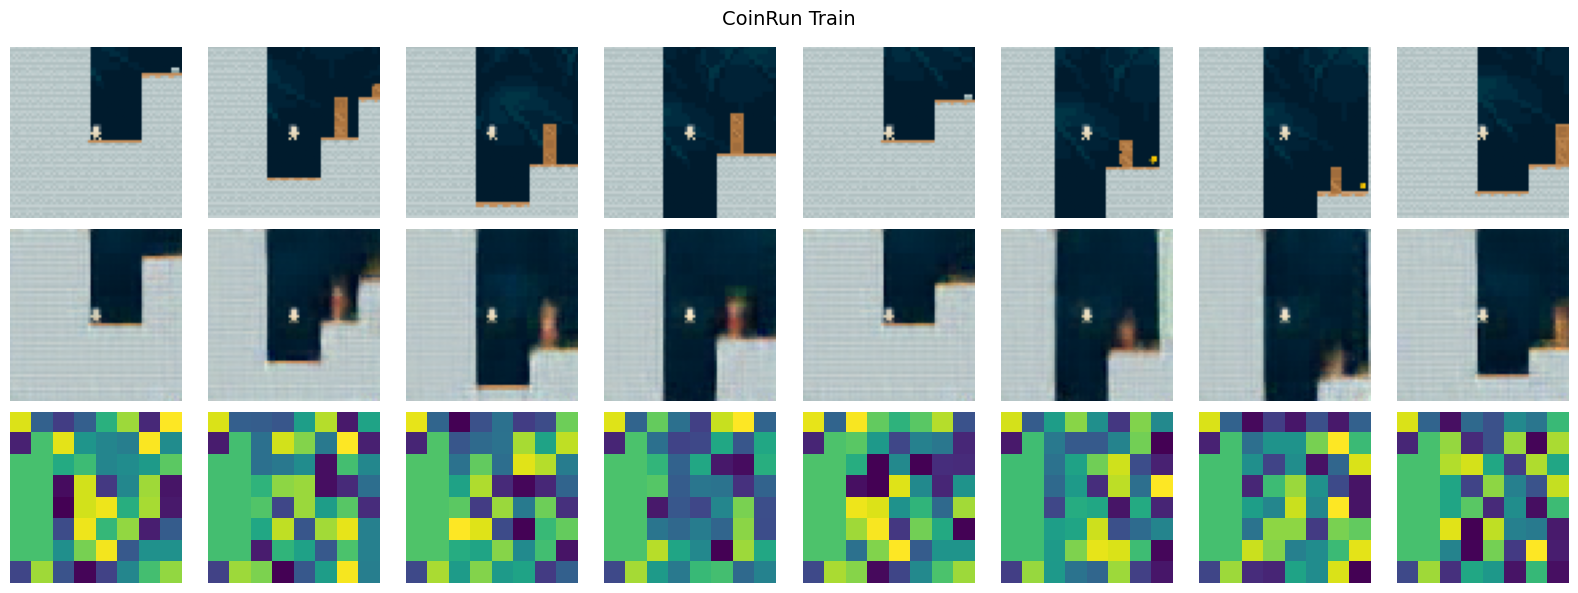

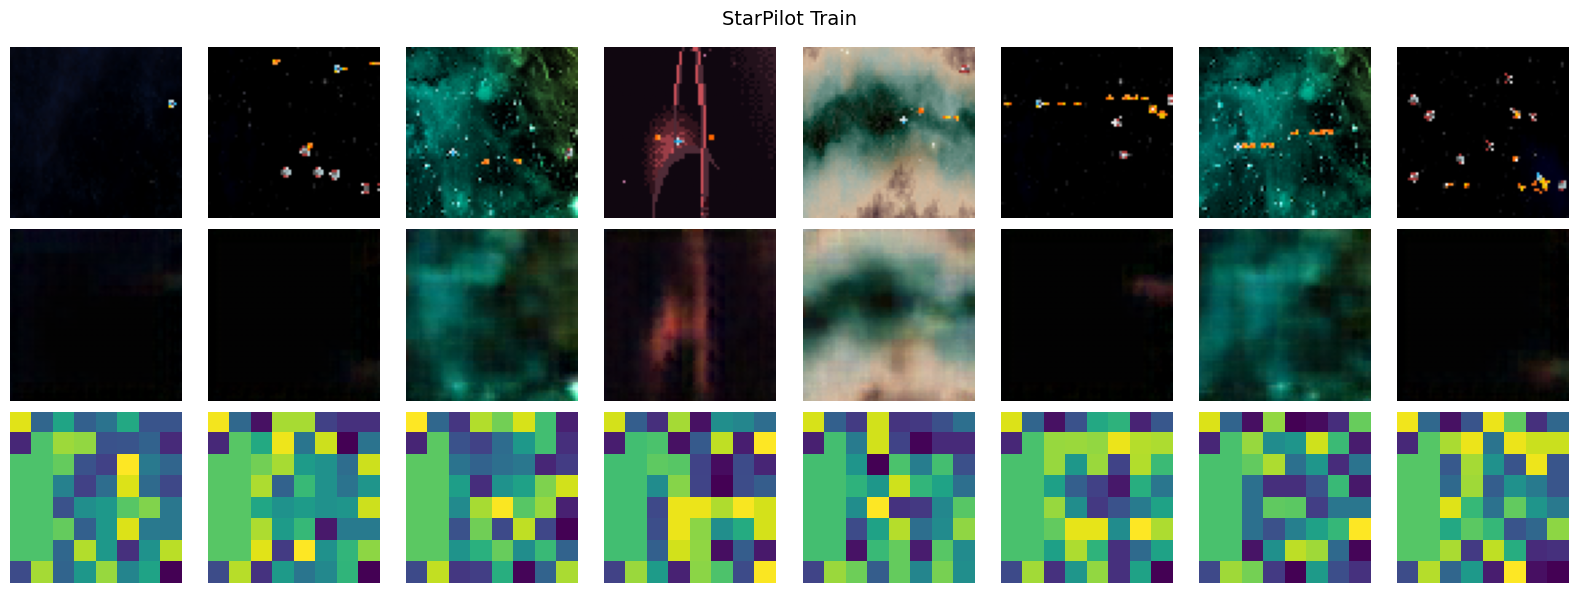

In [57]:
visualize_reconstructions(coinrun_test, "CoinRun Test (Unseen Levels)")
visualize_reconstructions(starpilot_test, "StarPilot Test (Unseen Levels)")

# Also show train set reconstructions for comparison
visualize_reconstructions(coinrun_train, "CoinRun Train")
visualize_reconstructions(starpilot_train, "StarPilot Train")

In [58]:
#Compute evaluation metrics (PSNR, SSIM)
def compute_psnr(original, reconstructed):
    """Peak Signal-to-Noise Ratio — higher is better."""
    mse = F.mse_loss(reconstructed, original).item()
    if mse == 0:
        return float('inf')
    return 10 * log10(1.0 / mse)  # max pixel value is 1.0

def evaluate_dataset(dataset, name, n_samples=1000):
    """Compute average PSNR over n_samples frames."""
    model.eval()
    indices = np.linspace(0, len(dataset) - 1, min(n_samples, len(dataset)), dtype=int)

    psnr_values = []
    recon_losses = []

    with torch.no_grad():
        for start in range(0, len(indices), 64):
            batch_idx = indices[start:start + 64]
            frames = torch.stack([dataset[i] for i in batch_idx]).to(device)
            recon, _, _ = model(frames)
            recon = recon.clamp(0, 1)

            for i in range(len(frames)):
                psnr_values.append(compute_psnr(frames[i], recon[i]))
                recon_losses.append(F.mse_loss(recon[i], frames[i]).item())

    avg_psnr = np.mean(psnr_values)
    avg_mse = np.mean(recon_losses)
    print(f"{name:30s} | PSNR: {avg_psnr:.2f} dB | MSE: {avg_mse:.6f}")
    return avg_psnr, avg_mse

In [59]:
print("\n=== VQ-VAE Reconstruction Quality ===\n")
evaluate_dataset(coinrun_train, "CoinRun Train (seen)")
evaluate_dataset(coinrun_test, "CoinRun Test (unseen)")
evaluate_dataset(starpilot_train, "StarPilot Train (seen)")
evaluate_dataset(starpilot_test, "StarPilot Test (unseen)")


=== VQ-VAE Reconstruction Quality ===

CoinRun Train (seen)           | PSNR: 24.39 dB | MSE: 0.004976
CoinRun Test (unseen)          | PSNR: 21.98 dB | MSE: 0.014334
StarPilot Train (seen)         | PSNR: 21.54 dB | MSE: 0.008265
StarPilot Test (unseen)        | PSNR: 21.61 dB | MSE: 0.008199


(np.float64(21.610000104027385), np.float64(0.00819923754152842))

In [60]:
# Tokenize the dataset using trained VQ-VAE

model.eval()
TOKENIZED_DIR = "/content/drive/MyDrive/procgen_tokenized"
os.makedirs(TOKENIZED_DIR, exist_ok=True)

def tokenize_dataset(h5_path, output_path):
    """Run all frames through VQ-VAE encoder, save token IDs + actions."""
    with h5py.File(h5_path, "r") as f:
        num_frames = f["frames"].shape[0]
        actions = f["actions"][:]
        dones = f["dones"][:]

        all_tokens = []

        # Process in batches
        batch_size = 256
        with torch.no_grad():
            for start in tqdm(range(0, num_frames, batch_size),
                            desc=os.path.basename(h5_path)):
                end = min(start + batch_size, num_frames)
                frames = f["frames"][start:end].astype(np.float32) / 255.0
                frames = np.transpose(frames, (0, 3, 1, 2))  # [B, 3, 64, 64]
                frames = torch.tensor(frames).to(device)

                tokens = model.encode(frames)  # [B, 8, 8]
                all_tokens.append(tokens.cpu().numpy())

    all_tokens = np.concatenate(all_tokens, axis=0)  # [N, 8, 8]

    # Save tokenized data
    with h5py.File(output_path, "w") as f:
        f.create_dataset("tokens", data=all_tokens.astype(np.int16),
                         compression="gzip")
        f.create_dataset("actions", data=actions, compression="gzip")
        f.create_dataset("dones", data=dones, compression="gzip")

    size_mb = os.path.getsize(output_path) / (1024 ** 2)
    print(f"  Saved: {output_path} ({size_mb:.1f} MB)")
    print(f"  Tokens shape: {all_tokens.shape}")
    print(f"  Token range: {all_tokens.min()} - {all_tokens.max()}")

# Tokenize all datasets
for split in ["coinrun_train", "coinrun_test", "starpilot_train", "starpilot_test"]:
    tokenize_dataset(
        os.path.join(DATA_DIR, f"{split}.h5"),
        os.path.join(TOKENIZED_DIR, f"{split}_tokens.h5"),
    )

print("\nTokenization complete!")

coinrun_train.h5: 100%|██████████| 391/391 [00:12<00:00, 30.16it/s]


  Saved: /content/drive/MyDrive/procgen_tokenized/coinrun_train_tokens.h5 (3.2 MB)
  Tokens shape: (100000, 8, 8)
  Token range: 0 - 511


coinrun_test.h5: 100%|██████████| 79/79 [00:02<00:00, 30.07it/s]


  Saved: /content/drive/MyDrive/procgen_tokenized/coinrun_test_tokens.h5 (0.6 MB)
  Tokens shape: (20000, 8, 8)
  Token range: 0 - 511


starpilot_train.h5: 100%|██████████| 391/391 [00:17<00:00, 22.14it/s]


  Saved: /content/drive/MyDrive/procgen_tokenized/starpilot_train_tokens.h5 (2.2 MB)
  Tokens shape: (100000, 8, 8)
  Token range: 0 - 511


starpilot_test.h5: 100%|██████████| 79/79 [00:03<00:00, 21.73it/s]


  Saved: /content/drive/MyDrive/procgen_tokenized/starpilot_test_tokens.h5 (0.6 MB)
  Tokens shape: (20000, 8, 8)
  Token range: 0 - 510

Tokenization complete!
